# Baseline & Profiling

**Goal:** Load GPT-2 124M, measure baseline tokens/sec, and profile to identify bottlenecks.

This notebook is a thin wrapper — all logic lives in `src/` modules.

In [1]:
import sys
sys.path.insert(0, "..")

from src.model import load_model_and_tokenizer
from src.inference import generate, generate_manual
from src.profiling import profile_generate, get_model_memory_footprint, save_profile
from src.benchmark import run_benchmark, compare_benchmarks, plot_speedups
from src.config import QUALITY_CHECK_PROMPTS

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Model

In [2]:
model, tokenizer = load_model_and_tokenizer()
print(f"Model: {model.config._name_or_path}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: gpt2
Parameters: 124,439,808


In [3]:
mem = get_model_memory_footprint(model)
for k, v in mem.items():
    print(f"  {k}: {v}")

  num_parameters: 124439808
  param_memory_mb: 474.7001953125
  buffer_memory_mb: 12.000045776367188
  total_memory_mb: 486.7002410888672
  dtype: torch.float32


## 2. Quick Sanity Check

Generate a few tokens to make sure the model is working.

In [4]:
result = generate(model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"tok/s: {result['tok_per_sec']:.2f}")
print(f"Text:  {result['text'][:300]}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


tok/s: 37.27
Text:  The meaning of life is to be free from injustice, suffering, oppression, and suffering.

So where did the name come from?

Babylon - (Egyptian:

Hakim, or God) is an Arab Arabic word meaning "God


## 3. Profile: HuggingFace `generate` vs Manual Loop

We profile both to understand where time is spent.

In [5]:
# Profile the HuggingFace built-in generate
hf_profile = profile_generate(
    model, tokenizer, "The meaning of life is", generate_fn=generate, max_new_tokens=50
)
print("=== HuggingFace generate() profile ===")
print(hf_profile["profile_stats"])

=== HuggingFace generate() profile ===
         136680 function calls (118436 primitive calls) in 0.668 seconds

   Ordered by: cumulative time
   List reduced from 447 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/1    0.000    0.000    0.667    0.667 _contextlib.py:113(decorate_context)
      2/1    0.000    0.000    0.667    0.667 inference.py:17(generate)
        1    0.000    0.000    0.667    0.667 utils.py:2245(generate)
        1    0.002    0.002    0.664    0.664 utils.py:3508(_sample)
  7550/50    0.004    0.000    0.605    0.012 module.py:1747(_wrapped_call_impl)
  7550/50    0.008    0.000    0.604    0.012 module.py:1755(_call_impl)
       50    0.001    0.000    0.604    0.012 modeling_gpt2.py:1038(forward)
       50    0.002    0.000    0.475    0.009 modeling_gpt2.py:776(forward)
      600    0.001    0.000    0.467    0.001 modeling_layers.py:61(__call__)
 1202/602    0.003    0.000    0.465    0.001 dep

In [6]:
# Profile the manual loop (this is what we'll optimize)
manual_profile = profile_generate(
    model, tokenizer, "The meaning of life is", generate_fn=generate_manual, max_new_tokens=50
)
print("=== Manual loop profile ===")
print(manual_profile["profile_stats"])

=== Manual loop profile ===
         125893 function calls (108088 primitive calls) in 1.499 seconds

   Ordered by: cumulative time
   List reduced from 341 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    1.499    1.499 _contextlib.py:113(decorate_context)
        1    0.004    0.004    1.498    1.498 inference.py:60(generate_manual)
  7550/50    0.006    0.000    1.449    0.029 module.py:1747(_wrapped_call_impl)
  7550/50    0.010    0.000    1.449    0.029 module.py:1755(_call_impl)
       50    0.001    0.000    1.448    0.029 modeling_gpt2.py:1038(forward)
       50    0.005    0.000    1.103    0.022 modeling_gpt2.py:776(forward)
      600    0.001    0.000    1.079    0.002 modeling_layers.py:61(__call__)
 1200/600    0.004    0.000    1.075    0.002 deprecation.py:120(wrapped_func)
      600    0.011    0.000    1.073    0.002 modeling_gpt2.py:398(forward)
     2400    0.005    0.000    0.756 

In [7]:
# Save .prof file for detailed analysis (e.g., snakeviz)
save_profile(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual,
    output_path="../profiling_output/baseline_manual.prof",
    max_new_tokens=50,
)

{'text': 'The meaning of life is eternal and the universe is not. There\'s not more to life than this world being this or that. It\'s not the end, but the beginning. Just like this world not saying, \'Look at everything,\'" the video of an interview with Stephen',
 'num_tokens': 50,
 'elapsed': 1.4087159999762662,
 'tok_per_sec': 35.49331447988267}

## 4. Baseline Benchmark

Full benchmark: 10 prompts × 5 runs each, 200 tokens per run.

In [8]:
print("Benchmarking HuggingFace generate()...")
hf_results = run_benchmark(
    model, tokenizer, generate,
    label="baseline_hf_generate",
    save_path="../benchmark_results/baseline_hf.json",
)
print(f"\nOverall: {hf_results['overall_tok_per_sec_mean']:.2f} ± {hf_results['overall_tok_per_sec_std']:.2f} tok/s")

Benchmarking HuggingFace generate()...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/baseline_hf.json

Overall: 78.36 ± 5.12 tok/s


In [9]:
print("Benchmarking manual loop...")
manual_results = run_benchmark(
    model, tokenizer, generate_manual,
    label="baseline_manual_loop",
    save_path="../benchmark_results/baseline_manual.json",
)
print(f"\nOverall: {manual_results['overall_tok_per_sec_mean']:.2f} ± {manual_results['overall_tok_per_sec_std']:.2f} tok/s")

Benchmarking manual loop...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/baseline_manual.json

Overall: 20.19 ± 5.33 tok/s


In [10]:
compare_benchmarks([hf_results, manual_results])


Label                       tok/s (mean)    tok/s (std)    Speedup
-----------------------------------------------------------------
baseline_hf_generate               78.36           5.12      1.00x
baseline_manual_loop               20.19           5.33      0.26x


  Plot saved to ../benchmark_results/baseline_comparison.png


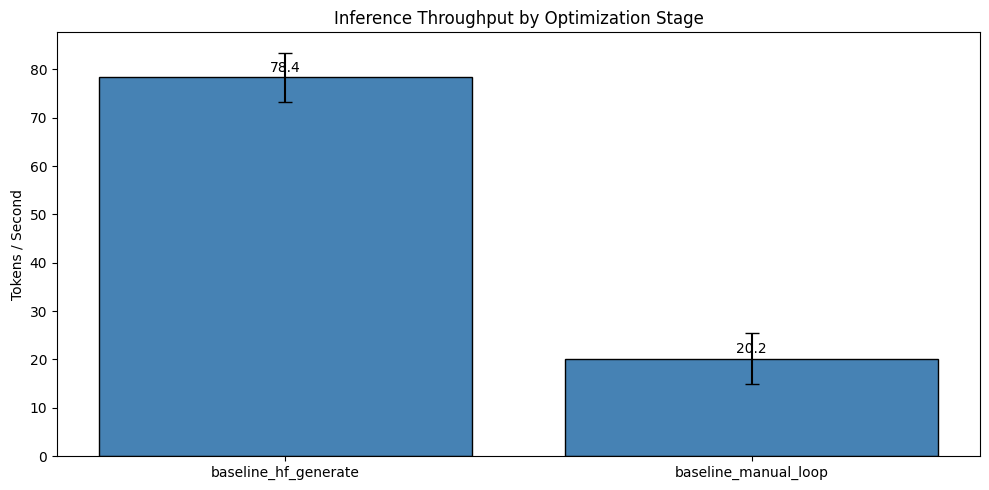

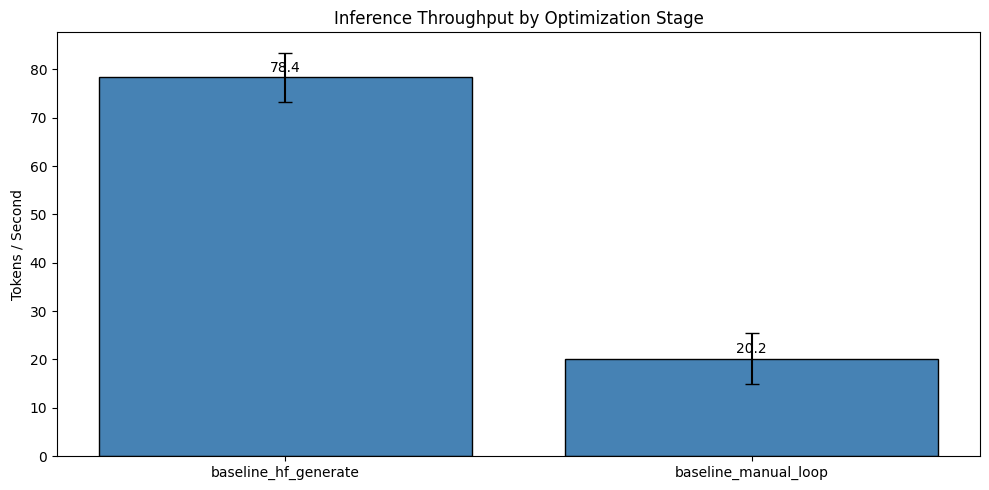

In [11]:
fig = plot_speedups(
    [hf_results, manual_results],
    save_path="../benchmark_results/baseline_comparison.png",
)
fig

## 5. Quality Sanity Check

Verify both methods produce reasonable outputs for factual prompts.

In [12]:
for prompt in QUALITY_CHECK_PROMPTS:
    hf_out = generate(model, tokenizer, prompt, max_new_tokens=30)
    manual_out = generate_manual(model, tokenizer, prompt, max_new_tokens=30)
    print(f"Prompt: {prompt}")
    print(f"  HF:     {hf_out['text'][:150]}")
    print(f"  Manual: {manual_out['text'][:150]}")
    print()

Prompt: What is 2 + 2? The answer is
  HF:     What is 2 + 2? The answer is no, to make sure you can hear the music I just mentioned. One is a low frequency to mono source. The other is stereo. Yes
  Manual: What is 2 + 2? The answer is: One does not exist, or at least in this situation, and there is neither one nor infinity. Both exist according to the la

Prompt: The capital of France is
  HF:     The capital of France is located off the Rhine-Westphalia.

France is situated within a large and fertile soil that lies to the north along the French
  Manual: The capital of France is surrounded by a number of other towns, suburbs and cities, as well as many castles and cities. There are many major rivers an

Prompt: Water freezes at
  HF:     Water freezes at around 150F (85C).

This temperature should continue to rise until the temperature of the ice begins to shrink before reaching the po
  Manual: Water freezes at 100 degrees, but the resulting precipitation will drop far more quickly